<a href="https://colab.research.google.com/github/mfernandezzz/Data-Analysis-Projects/blob/main/sea_level_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

**The objective of this project is know how to create a predictive analisis and visualize the prediction in a chart.**

**Analyze a dataset of the global average sea level change since 1880 to predict the sea level change through year 2050. Create a scatter plot using the Year column as the x-axis and the CSIRO Adjusted Sea Level column as the y-axis. Use the linregress function from scipy.stats to get the slope and y-intercept of the line of best fit. Plot the line of best fit (over the top of the scatter plot) through the year 2050 to predict the sea level rise. Plot a new line of best fit just using the data from year 2000 through the year 2050 to predict the sea level rise if the rate of rise continues as it has since the year 2000. The x label should be Year, the y label should be Sea Level (inches), and the title should be Rise in Sea Level.**

In [24]:
df = pd.read_csv('/content/epa-sea-level.csv')
df.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN


In [25]:
df.dtypes

,0
Year,int64
CSIRO Adjusted Sea Level,float64
Lower Error Bound,float64
Upper Error Bound,float64
NOAA Adjusted Sea Level,float64


In [26]:
df.columns = (df.columns
              .str.strip()
              .str.replace(' ', '_')
              .str.lower()
              )
df.head()

,year,csiro_adjusted_sea_level,lower_error_bound,upper_error_bound,noaa_adjusted_sea_level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN


In [27]:
df['csiro_adjusted_sea_level'].isna().sum()

np.int64(10)

In [28]:
df.shape

(144, 5)

Clean data by removing rows where the target column is NAN

In [29]:
df_clean = df[df['csiro_adjusted_sea_level'].notna()]
# df_clean = df.dropna(subset=['csiro_adjusted_sea_level'])
df_clean.shape

(134, 5)

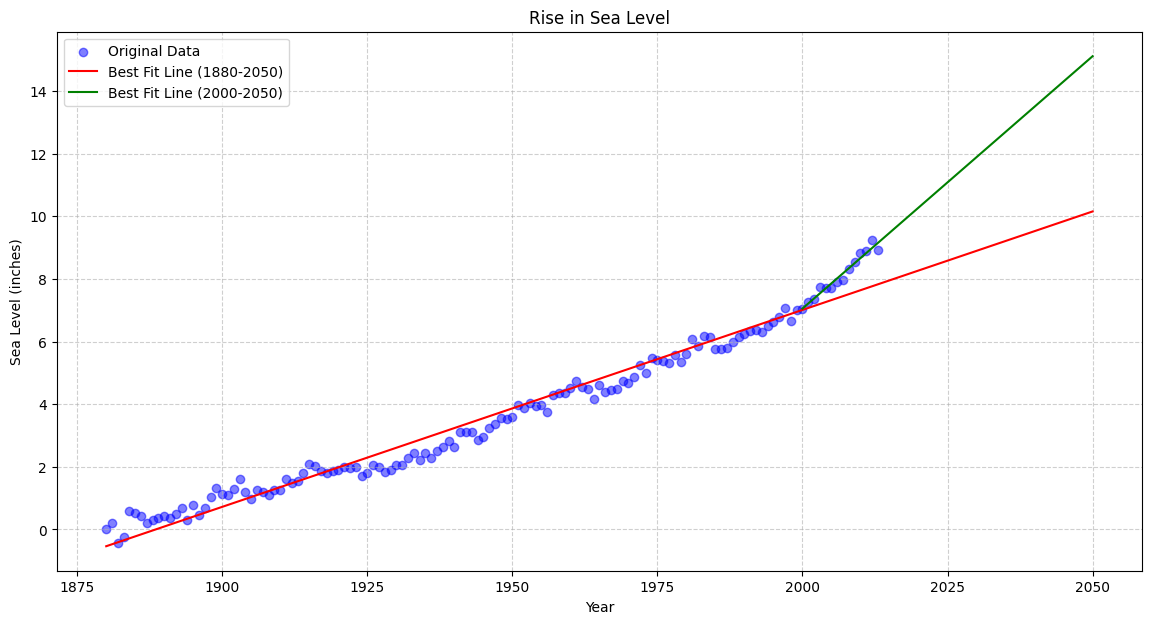

In [30]:
# Create scatter plot
plt.figure(figsize=(14, 7))
plt.scatter(df_clean['year'], df_clean['csiro_adjusted_sea_level'], color='blue', alpha=0.5, label='Original Data')

# First line of best fit (all data from 1880 to 2050)
res_all = linregress(df_clean['year'], df_clean['csiro_adjusted_sea_level'])
x_pred_all = np.arange(df_clean['year'].min(), 2051)
y_pred_all = res_all.slope * x_pred_all + res_all.intercept
plt.plot(x_pred_all, y_pred_all, color='red', label='Best Fit Line (1880-2050)')

# Second line of best fit (data from year 2000 onwards to 2050)
df_recent = df_clean[df_clean['year'] >= 2000]
res_recent = linregress(df_recent['year'], df_recent['csiro_adjusted_sea_level'])
x_pred_recent = np.arange(2000, 2051)
y_pred_recent = res_recent.slope * x_pred_recent + res_recent.intercept
plt.plot(x_pred_recent, y_pred_recent, color='green', label='Best Fit Line (2000-2050)')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Sea Level (inches)')
plt.title('Rise in Sea Level')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()